In [131]:
import subprocess, sys
for pkg in ["open3d","numpy","scikit-learn","matplotlib","pandas"]:
    subprocess.check_call([sys.executable,"-m","pip","install",pkg,"-q"])
print("✅ All packages ready")


✅ All packages ready


In [132]:
import os, time, warnings
warnings.filterwarnings('ignore')
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import pandas as pd
from sklearn.cluster import DBSCAN
from collections import Counter
print(f"numpy  {np.__version__}")
print(f"open3d {o3d.__version__}")
print("✅ Imports OK")


numpy  1.24.3
open3d 0.19.0
✅ Imports OK


In [133]:

DATASET_ROOT = r"C:\Desktop\s3dis_project\s3dis_project\Stanford3dDataset_v1.2_Aligned_Version"

AREA = "Area_1"
ROOM = "conferenceRoom_1"   

OUTPUT_DIR = "./output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.isdir(DATASET_ROOT):
    print("❌  Folder NOT found — fix DATASET_ROOT above")
else:
    print("✅  Dataset found!\nAvailable rooms:")
    for area in sorted(os.listdir(DATASET_ROOT)):
        ap = os.path.join(DATASET_ROOT, area)
        if not os.path.isdir(ap) or area.startswith('.'): continue
        rooms = [r for r in sorted(os.listdir(ap))
                 if os.path.isdir(os.path.join(ap,r)) and not r.startswith('.')]
        print(f"  {area}:")
        for r in rooms:
            txt = os.path.join(ap,r,f"{r}.txt")
            ann = os.path.join(ap,r,"Annotations")
            has_txt = os.path.isfile(txt)
            has_ann = os.path.isdir(ann)
            mb  = f"{os.path.getsize(txt)/1e6:.0f}MB" if has_txt else ""
            flag = "✅" if (has_txt and has_ann) else "⚠️"
            print(f"      {r:<26} {flag}  {mb}")
    print()
    room_file = os.path.join(DATASET_ROOT, AREA, ROOM, f"{ROOM}.txt")
    ann_dir   = os.path.join(DATASET_ROOT, AREA, ROOM, "Annotations")
    if os.path.isfile(room_file):
        print(f"Selected: {AREA}/{ROOM}  ({os.path.getsize(room_file)/1e6:.1f}MB)  ✅")
        n_ann = len([f for f in os.listdir(ann_dir) if f.endswith('.txt')]) if os.path.isdir(ann_dir) else 0
        print(f"Annotation files: {n_ann}")
    else:
        print(f"❌  Not found: {room_file}")


✅  Dataset found!
Available rooms:
  Area_1:
      WC_1                       ✅  36MB
      conferenceRoom_1           ✅  37MB
      conferenceRoom_2           ✅  47MB
      copyRoom_1                 ✅  16MB
      hallway_1                  ✅  11MB
      hallway_2                  ✅  18MB
      hallway_3                  ✅  11MB
      hallway_4                  ✅  11MB
      hallway_5                  ✅  15MB
      hallway_6                  ✅  123MB
      hallway_7                  ✅  104MB
      hallway_8                  ✅  39MB
      office_1                   ✅  28MB
      office_10                  ✅  25MB
      office_11                  ✅  26MB
      office_12                  ✅  25MB
      office_13                  ✅  22MB
      office_14                  ✅  22MB
      office_15                  ✅  14MB
      office_16                  ✅  43MB
      office_17                  ✅  27MB
      office_18                  ✅  25MB
      office_19                  ✅  26MB
      offi

In [134]:

CAT_MAP = {
    'floor'   :'floor',    'ceiling' :'ceiling',  'wall'    :'wall',
    'beam'    :'beam',     'column'  :'beam',
    'window'  :'window',   'door'    :'furniture',
    'table'   :'furniture','chair'   :'furniture', 'sofa'    :'furniture',
    'bookcase':'furniture','board'   :'furniture', 'clutter' :'furniture',
}

SEMANTIC_COLORS = {
    'floor'    : [0.20, 0.82, 0.20],  
    'ceiling'  : [0.75, 0.75, 0.75],  
    'wall'     : [0.25, 0.45, 0.95],  
    'beam'     : [0.60, 0.30, 0.10],  
    'window'   : [0.40, 0.90, 0.95],  
    'furniture': [0.95, 0.50, 0.10],  
    'noise'    : [0.20, 0.20, 0.20],  
}

def load_from_annotations(ann_dir, centre=True):
    """
    Load every .txt file in Annotations/, tag each point with its category.
    Returns xyz (Nx3), rgb (Nx3), semantic_labels (list of N strings).
    """
    all_xyz, all_rgb, all_labs = [], [], []
    files = sorted(f for f in os.listdir(ann_dir) if f.endswith('.txt'))
    print(f"Found {len(files)} annotation files:")

    for fn in files:
        cat    = fn.split('_')[0].lower()
        mapped = CAT_MAP.get(cat, 'furniture')
        fp     = os.path.join(ann_dir, fn)
        try:
            d = np.loadtxt(fp, dtype=np.float64)
            if d.ndim == 1: d = d.reshape(1,-1)
            if d.shape[1] < 3: continue
            xyz = d[:,:3]
            rgb = d[:,3:6] / 255.0 if d.shape[1] >= 6 else np.ones((len(d),3))*0.5
            rgb = np.clip(rgb, 0, 1)
            all_xyz.append(xyz)
            all_rgb.append(rgb)
            all_labs.extend([mapped]*len(d))
            print(f"  {fn:<28} → {mapped:<10}  ({len(d):,} pts)")
        except Exception as e:
            print(f"  ⚠️  {fn}: {e}")

    xyz = np.vstack(all_xyz).astype(np.float64)
    rgb = np.vstack(all_rgb).astype(np.float64)

    if centre:
        xyz[:,0] -= xyz[:,0].min()
        xyz[:,1] -= xyz[:,1].min()
        xyz[:,2] -= xyz[:,2].min()

    return xyz, rgb, all_labs

def load_room_raw(room_txt, centre=True):
    """Load main room .txt for raw-RGB preview."""
    with open(room_txt,'r',errors='replace') as f:
        first = f.readline().strip()
    try: [float(x) for x in first.split()]; skip=0
    except: skip=1
    try:
        data = np.loadtxt(room_txt, dtype=np.float64, skiprows=skip)
    except:
        rows=[]
        with open(room_txt,'r',errors='replace') as f:
            if skip: f.readline()
            for line in f:
                p=line.strip().split()
                if len(p)>=6:
                    try: rows.append([float(v) for v in p[:6]])
                    except: pass
        data=np.array(rows,dtype=np.float64)
    xyz=data[:,:3]; rgb=np.clip(data[:,3:6]/255,0,1)
    if centre:
        xyz[:,0]-=xyz[:,0].min(); xyz[:,1]-=xyz[:,1].min(); xyz[:,2]-=xyz[:,2].min()
    return xyz, rgb

room_file = os.path.join(DATASET_ROOT, AREA, ROOM, f"{ROOM}.txt")
ann_dir   = os.path.join(DATASET_ROOT, AREA, ROOM, "Annotations")

print("="*60)
print(f"  LOADING  {AREA}/{ROOM}")
print("="*60)
t0=time.time()
xyz_ann, rgb_ann, sem_labels_raw = load_from_annotations(ann_dir, centre=True)
print(f"\nTotal from annotations: {len(xyz_ann):,} pts  ({time.time()-t0:.1f}s)")
print(f"Z span: {xyz_ann[:,2].ptp():.2f} m  (should be 2-4 m)")


pcd_ann = o3d.geometry.PointCloud()
pcd_ann.points = o3d.utility.Vector3dVector(xyz_ann)
pcd_ann.colors = o3d.utility.Vector3dVector(rgb_ann)


cnt = Counter(sem_labels_raw); total=len(sem_labels_raw)
print("\nLabel distribution from annotations:")
for lbl in ['floor','ceiling','wall','beam','window','furniture']:
    n=cnt.get(lbl,0)
    bar='█'*int(30*n/max(total,1))
    print(f"  {lbl:<11} {n:>8,}  {100*n/total:5.1f}%  {bar}")
print("\n✅ Labels loaded from ground truth annotations!")


  LOADING  Area_1/conferenceRoom_1
Found 32 annotation files:
  beam_1.txt                   → beam        (61,528 pts)
  board_1.txt                  → furniture   (19,727 pts)
  board_2.txt                  → furniture   (33,747 pts)
  board_3.txt                  → furniture   (33,359 pts)
  bookcase_1.txt               → furniture   (20,437 pts)
  ceiling_1.txt                → ceiling     (213,074 pts)
  chair_1.txt                  → furniture   (6,729 pts)
  chair_10.txt                 → furniture   (6,326 pts)
  chair_11.txt                 → furniture   (4,331 pts)
  chair_12.txt                 → furniture   (3,971 pts)
  chair_13.txt                 → furniture   (4,663 pts)
  chair_2.txt                  → furniture   (5,652 pts)
  chair_3.txt                  → furniture   (4,689 pts)
  chair_4.txt                  → furniture   (4,974 pts)
  chair_5.txt                  → furniture   (8,782 pts)
  chair_6.txt                  → furniture   (9,360 pts)
  chair_7.txt      

In [135]:
def voxel_downsample_with_labels(xyz, rgb, labels, voxel_size=0.05):
   
    mins = xyz.min(axis=0)
    vi   = ((xyz - mins) / voxel_size).astype(int)
    keys = vi[:,0]*10_000_000 + vi[:,1]*10_000 + vi[:,2]

    order   = np.argsort(keys)
    keys_s  = keys[order]
    unique_keys, starts = np.unique(keys_s, return_index=True)
    stops   = np.append(starts[1:], len(keys_s))

    out_xyz, out_rgb, out_lab = [], [], []
    lab_arr = np.array(labels)
    for s,e in zip(starts,stops):
        idx = order[s:e]
        out_xyz.append(xyz[idx].mean(axis=0))
        out_rgb.append(rgb[idx].mean(axis=0))
        # majority label
        c = Counter(lab_arr[idx].tolist())
        out_lab.append(c.most_common(1)[0][0])

    out_xyz = np.array(out_xyz)
    out_rgb = np.array(out_rgb)
    return out_xyz, out_rgb, out_lab

print("Downsampling …")
t0=time.time()
xyz_ds, rgb_ds, sem_labels = voxel_downsample_with_labels(xyz_ann, rgb_ann, sem_labels_raw, voxel_size=0.05)
print(f"  {len(xyz_ann):,} → {len(xyz_ds):,} pts  ({time.time()-t0:.1f}s)")

cnt=Counter(sem_labels); total=len(sem_labels)
print("\nLabel distribution after downsample:")
for lbl in ['floor','ceiling','wall','beam','window','furniture']:
    n=cnt.get(lbl,0)
    bar='█'*int(30*n/max(total,1))
    print(f"  {lbl:<11} {n:>8,}  {100*n/total:5.1f}%  {bar}")
print("\n✅ Downsample done")


Downsampling …
  1,136,617 → 50,016 pts  (1.5s)

Label distribution after downsample:
  floor          8,284   16.6%  ████
  ceiling        8,943   17.9%  █████
  wall          14,851   29.7%  ████████
  beam           2,485    5.0%  █
  window             0    0.0%  
  furniture     15,453   30.9%  █████████

✅ Downsample done


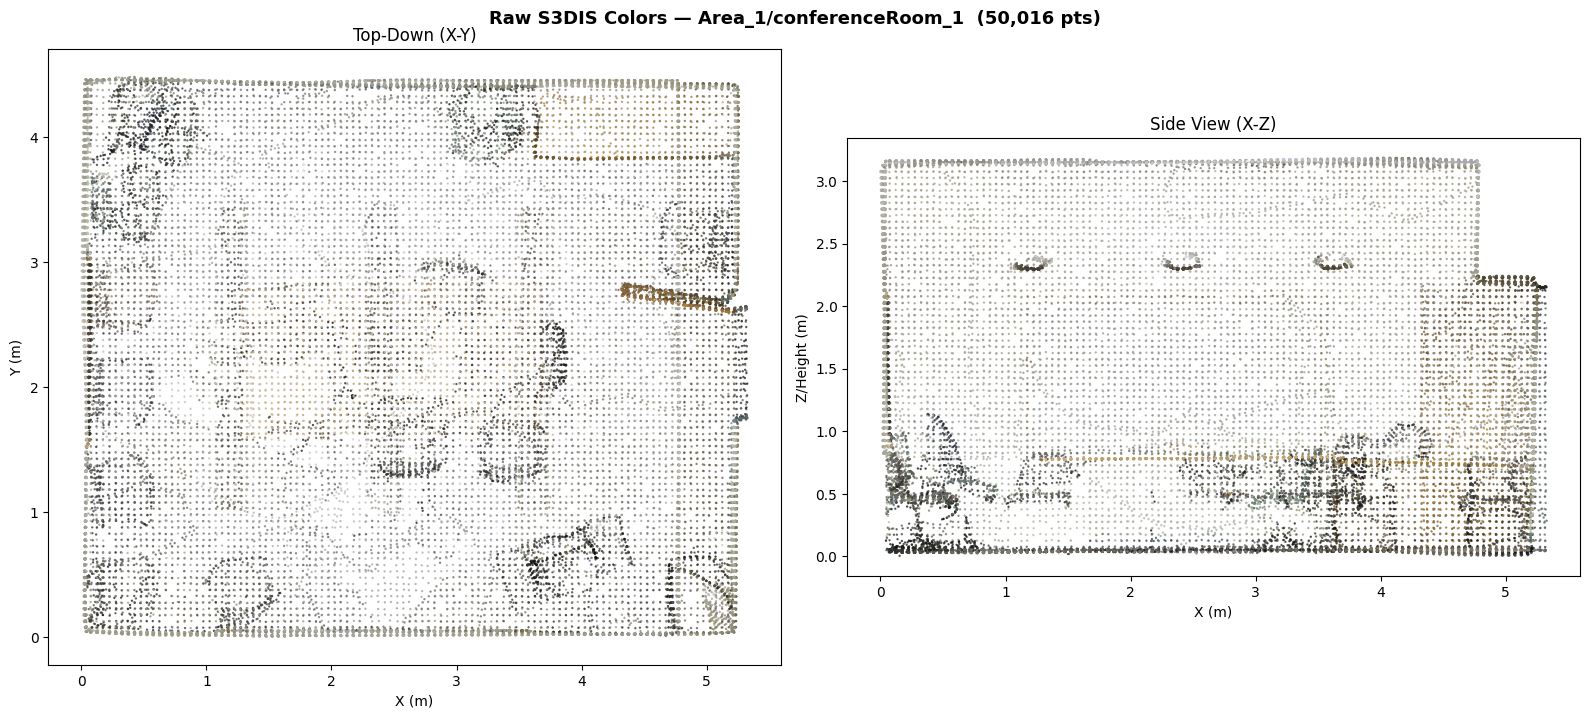

Saved → ./output\01_raw_rgb.png


In [136]:
def subsample(arr, n=40_000):
    return arr[np.random.choice(len(arr),n,replace=False)] if len(arr)>n else arr

def plot_raw(xyz, rgb, title, out_dir):
    idx = np.random.choice(len(xyz), min(40_000,len(xyz)), replace=False)
    p=xyz[idx]; c=rgb[idx]
    fig,axes=plt.subplots(1,2,figsize=(16,7))
    fig.suptitle(title,fontsize=13,fontweight='bold')
    axes[0].scatter(p[:,0],p[:,1],c=c,s=0.5,alpha=0.7,rasterized=True)
    axes[0].set_title("Top-Down (X-Y)"); axes[0].set_xlabel("X (m)"); axes[0].set_ylabel("Y (m)")
    axes[0].set_aspect('equal')
    axes[1].scatter(p[:,0],p[:,2],c=c,s=0.5,alpha=0.7,rasterized=True)
    axes[1].set_title("Side View (X-Z)"); axes[1].set_xlabel("X (m)"); axes[1].set_ylabel("Z/Height (m)")
    axes[1].set_aspect('equal')
    plt.tight_layout()
    out=os.path.join(out_dir,"01_raw_rgb.png")
    plt.savefig(out,dpi=120,bbox_inches='tight'); plt.show()
    print(f"Saved → {out}")

plot_raw(xyz_ds, rgb_ds,
         f"Raw S3DIS Colors — {AREA}/{ROOM}  ({len(xyz_ds):,} pts)", OUTPUT_DIR)


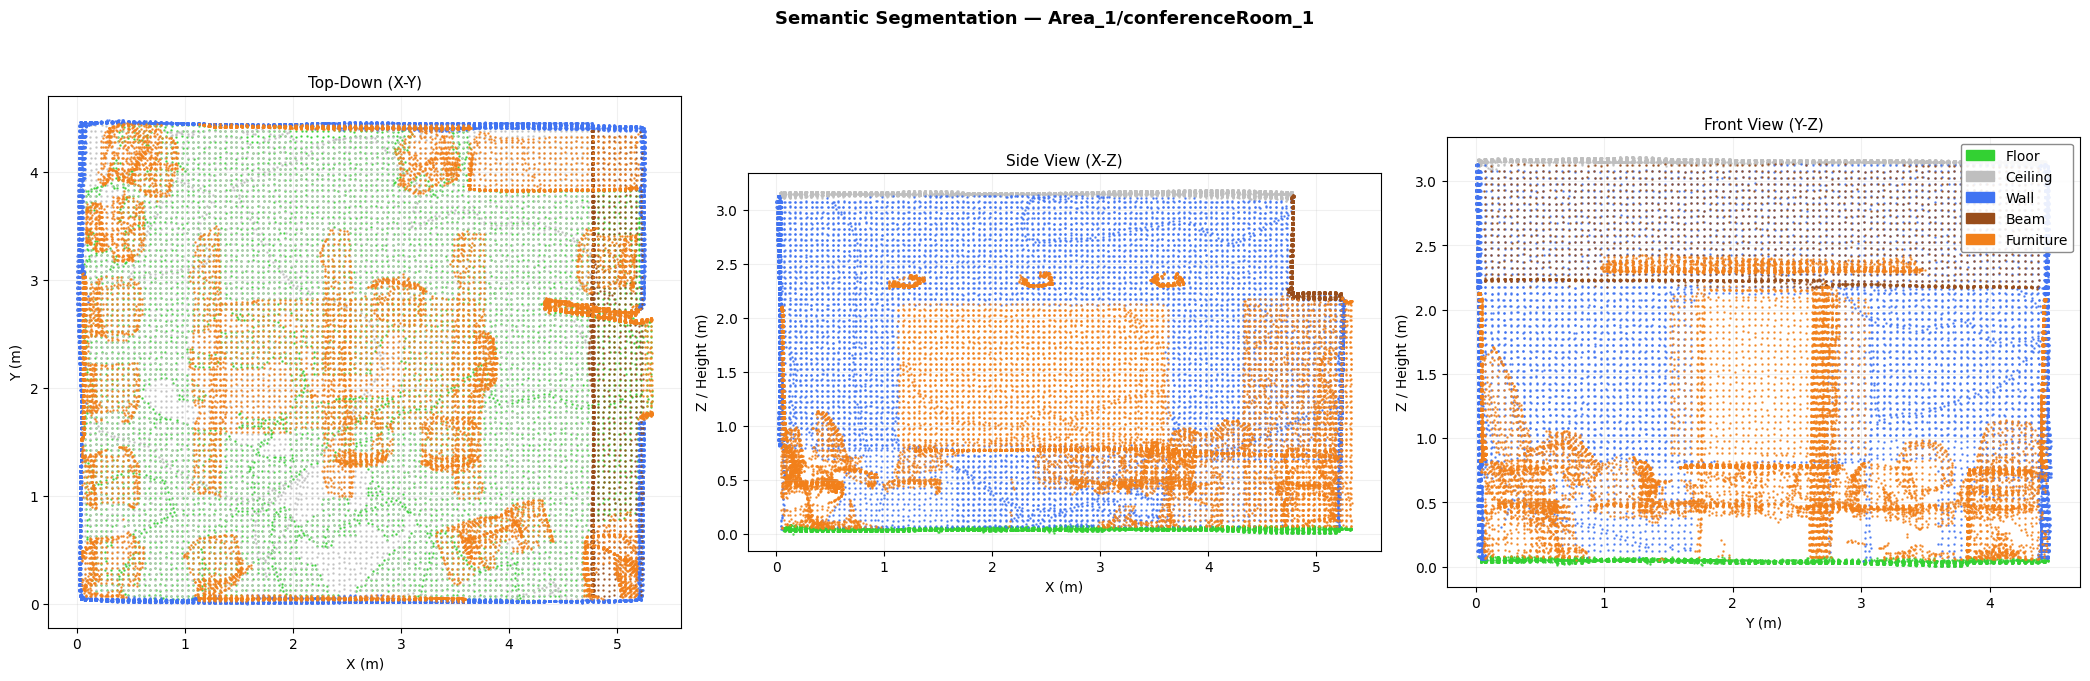

Saved → ./output\02_segmentation_2d.png
✅ Done


In [137]:
def plot_semantic_3view(xyz, labels, color_map, title, out_dir):
    labs = np.array(labels)
    N    = min(50_000, len(xyz))
    idx  = np.random.choice(len(xyz), N, replace=False)
    p    = xyz[idx]; l = labs[idx]
    default=[0.5,0.5,0.5]

    fig, axes = plt.subplots(1,3,figsize=(21,7))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    views=[
        (0,1,"Top-Down (X-Y)","X (m)","Y (m)"),
        (0,2,"Side View (X-Z)","X (m)","Z / Height (m)"),
        (1,2,"Front View (Y-Z)","Y (m)","Z / Height (m)"),
    ]
    label_order=['floor','ceiling','wall','beam','window','furniture','noise']
    for ax,(xi,yi,t,xl,yl) in zip(axes,views):
        for lbl in label_order:
            m = l==lbl
            if not m.any(): continue
            col=color_map.get(lbl,default)
            ax.scatter(p[m,xi],p[m,yi],c=[col],s=0.6,alpha=0.80,label=lbl,rasterized=True)
        ax.set_title(t,fontsize=11); ax.set_xlabel(xl); ax.set_ylabel(yl)
        ax.set_aspect('equal'); ax.grid(alpha=0.18)

    patches=[mpatches.Patch(color=color_map.get(l,default),label=l.capitalize())
             for l in label_order if (np.array(labels)==l).any()]
    axes[2].legend(handles=patches,loc='upper right',fontsize=10,
                   framealpha=0.9,edgecolor='grey')
    plt.tight_layout()
    out=os.path.join(out_dir,"02_segmentation_2d.png")
    plt.savefig(out,dpi=140,bbox_inches='tight'); plt.show()
    print(f"Saved → {out}")

print("="*60)
plot_semantic_3view(xyz_ds, sem_labels, SEMANTIC_COLORS,
                    f"Semantic Segmentation — {AREA}/{ROOM}", OUTPUT_DIR)
print("✅ Done")


In [138]:

DBSCAN_PARAMS = {
    'floor'    : dict(eps=0.30, min_samples=20),
    'ceiling'  : dict(eps=0.30, min_samples=20),
    'wall'     : dict(eps=0.20, min_samples=15),
    'beam'     : dict(eps=0.15, min_samples=10),
    'window'   : dict(eps=0.15, min_samples=10),
    'furniture': dict(eps=0.08, min_samples=10),  
}

def dbscan_per_class(xyz, labels):
    """Run DBSCAN separately for each semantic class."""
    labs    = np.array(labels)
    n       = len(xyz)
    cl_ids  = np.full(n, -1, dtype=int)
    offset  = 0   

    all_stats = []
    for cls, params in DBSCAN_PARAMS.items():
        mask = labs == cls
        if not mask.any(): continue
        pts_cls = xyz[mask]
        print(f"  {cls:<11}: {mask.sum():>7,} pts   eps={params['eps']} ", end='')
        t0=time.time()
        db = DBSCAN(**params, algorithm='ball_tree', n_jobs=-1)
        sub_labels = db.fit_predict(pts_cls)
        n_cl   = int((sub_labels>=0).sum())
        n_noi  = int((sub_labels==-1).sum())
        elapsed= time.time()-t0
        print(f"→  {np.unique(sub_labels[sub_labels>=0]).size} clusters  "
              f"({n_noi} noise)  {elapsed:.1f}s")

        # assign globally unique cluster IDs
        idx_in_full = np.where(mask)[0]
        for cid in np.unique(sub_labels):
            if cid == -1: continue
            cidx = idx_in_full[sub_labels==cid]
            cl_ids[cidx] = cid + offset
            pts_c = xyz[cidx]
            all_stats.append({
                'cluster_id': int(cid+offset),
                'semantic'  : cls,
                'count'     : len(cidx),
                'x_spread'  : round(float(pts_c[:,0].ptp()),3),
                'y_spread'  : round(float(pts_c[:,1].ptp()),3),
                'z_spread'  : round(float(pts_c[:,2].ptp()),3),
                'cx'        : round(float(pts_c[:,0].mean()),3),
                'cy'        : round(float(pts_c[:,1].mean()),3),
                'cz'        : round(float(pts_c[:,2].mean()),3),
                'area_m2'   : round(float(pts_c[:,0].ptp()*pts_c[:,1].ptp()),3),
            })
        offset += int(sub_labels.max()+2) if sub_labels.max()>=0 else 1

    df_stats = pd.DataFrame(all_stats).sort_values('count',ascending=False)
    return cl_ids, df_stats

print("="*60)
print("  DBSCAN PER SEMANTIC CLASS")
print("="*60)
cluster_ids, df_clusters = dbscan_per_class(xyz_ds, sem_labels)
print(f"\nTotal clusters found: {df_clusters['cluster_id'].nunique()}")
print("\nTop 20 clusters:")
print(df_clusters.head(20).to_string(index=False))
print("\n✅ Clustering done")


  DBSCAN PER SEMANTIC CLASS
  floor      :   8,284 pts   eps=0.3 →  1 clusters  (0 noise)  0.1s
  ceiling    :   8,943 pts   eps=0.3 →  1 clusters  (0 noise)  0.1s
  wall       :  14,851 pts   eps=0.2 →  1 clusters  (29 noise)  0.1s
  beam       :   2,485 pts   eps=0.15 →  1 clusters  (0 noise)  0.0s
  furniture  :  15,453 pts   eps=0.08 →  65 clusters  (4428 noise)  0.1s

Total clusters found: 69

Top 20 clusters:
 cluster_id  semantic  count  x_spread  y_spread  z_spread    cx    cy    cz  area_m2
          4      wall  14822     5.258     4.477     3.085 2.461 2.261 1.734   23.539
          2   ceiling   8943     4.751     4.449     0.106 2.392 2.212 3.152   21.138
          0     floor   8284     5.255     4.431     0.078 2.605 2.183 0.044   23.285
          6      beam   2485     0.516     4.313     0.973 4.856 2.233 2.512    2.225
         63 furniture   1676     0.999     0.235     2.134 4.771 2.701 1.118    0.235
         67 furniture    633     0.505     0.798     1.637 4.977 

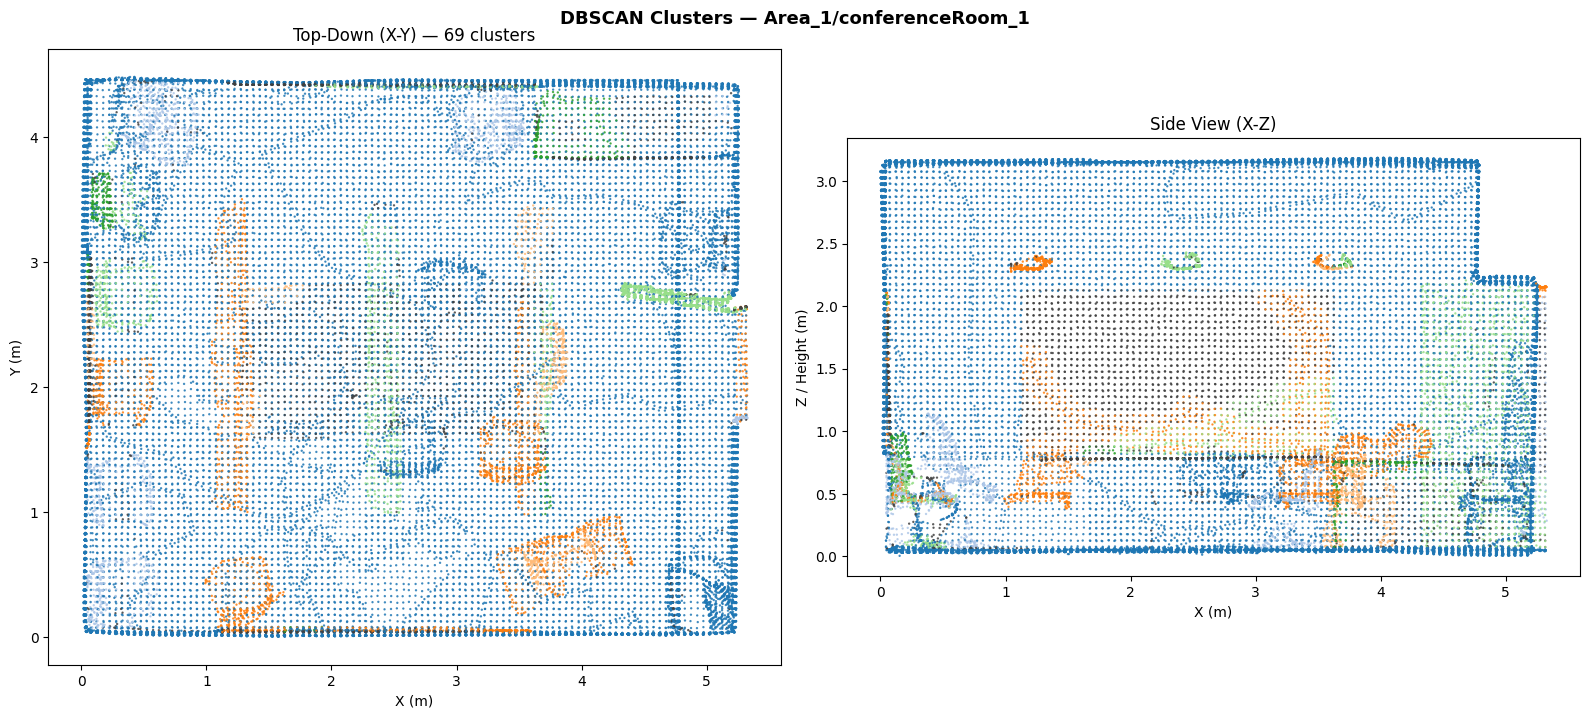

Saved → ./output\03_dbscan_clusters.png


In [139]:
def plot_dbscan_clusters(xyz, cl_ids, sem_labels, title, out_dir):
    labs = np.array(sem_labels)
    unique_cids = np.unique(cl_ids[cl_ids>=0])
    cmap = plt.cm.get_cmap('tab20', max(len(unique_cids),1))
    cols = np.full((len(xyz),3), 0.25)  
    for i,cid in enumerate(unique_cids):
        m = cl_ids==cid
        cols[m] = cmap(i%20)[:3]

    N   = min(50_000, len(xyz))
    idx = np.random.choice(len(xyz),N,replace=False)
    p=xyz[idx]; c=cols[idx]

    fig,axes=plt.subplots(1,2,figsize=(16,7))
    fig.suptitle(title,fontsize=13,fontweight='bold')
    axes[0].scatter(p[:,0],p[:,1],c=c,s=0.5,alpha=0.8,rasterized=True)
    axes[0].set_title(f"Top-Down (X-Y) — {len(unique_cids)} clusters")
    axes[0].set_xlabel("X (m)"); axes[0].set_ylabel("Y (m)"); axes[0].set_aspect('equal')
    axes[1].scatter(p[:,0],p[:,2],c=c,s=0.5,alpha=0.8,rasterized=True)
    axes[1].set_title("Side View (X-Z)")
    axes[1].set_xlabel("X (m)"); axes[1].set_ylabel("Z / Height (m)"); axes[1].set_aspect('equal')
    plt.tight_layout()
    out=os.path.join(out_dir,"03_dbscan_clusters.png")
    plt.savefig(out,dpi=130,bbox_inches='tight'); plt.show()
    print(f"Saved → {out}")

plot_dbscan_clusters(xyz_ds, cluster_ids, sem_labels,
                     f"DBSCAN Clusters — {AREA}/{ROOM}", OUTPUT_DIR)


In [140]:
def save_ply(xyz, sem_labels, color_map, path):
    cols=np.array([color_map.get(l,[0.5,0.5,0.5]) for l in sem_labels])
    pcd=o3d.geometry.PointCloud()
    pcd.points=o3d.utility.Vector3dVector(xyz)
    pcd.colors=o3d.utility.Vector3dVector(cols)
    o3d.io.write_point_cloud(path,pcd)
    print(f"✅ Saved .ply → {path}  ({os.path.getsize(path)/1e6:.1f} MB)")
    return pcd

pcd_colored = save_ply(xyz_ds, sem_labels, SEMANTIC_COLORS,
                        os.path.join(OUTPUT_DIR,"segmented_room.ply"))

csv_path = os.path.join(OUTPUT_DIR,"cluster_report.csv")
df_clusters.to_csv(csv_path,index=False)
print(f"✅ Saved .csv → {csv_path}")


✅ Saved .ply → ./output\segmented_room.ply  (1.4 MB)
✅ Saved .csv → ./output\cluster_report.csv


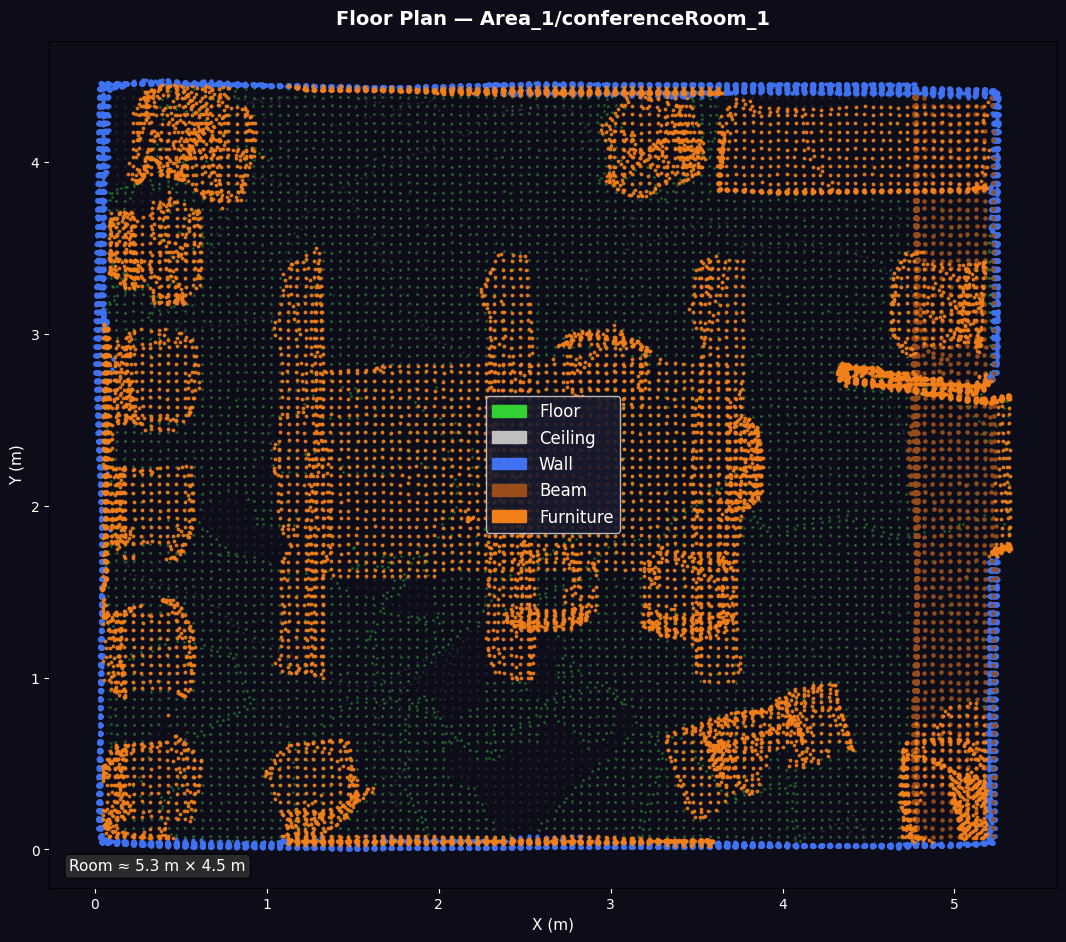

Saved → ./output\04_floor_plan.png


In [141]:
def floor_plan(xyz, labels, color_map, title, out_dir):
    labs=np.array(labels)
    fig,ax=plt.subplots(figsize=(13,13))
    ax.set_facecolor('#0d0d1a'); fig.patch.set_facecolor('#0d0d1a')

    draw_order=[
        ('floor',   0.30, 1.2),
        ('ceiling', 0.10, 0.8),
        ('wall',    0.95, 4.0),
        ('beam',    0.95, 5.0),
        ('window',  0.90, 3.5),
        ('furniture',0.85,3.0),
    ]
    legend_patches=[]
    for lbl,alpha,sz in draw_order:
        m=labs==lbl
        if not m.any(): continue
        col=color_map.get(lbl,[0.5,0.5,0.5])
        ax.scatter(xyz[m,0],xyz[m,1],c=[col],s=sz,alpha=alpha,rasterized=True)
        legend_patches.append(mpatches.Patch(color=col,label=lbl.capitalize()))

    ax.legend(handles=legend_patches,facecolor='#1a1a2e',
              labelcolor='white',fontsize=12,framealpha=0.9)
    ax.set_title(title,color='white',fontsize=14,fontweight='bold',pad=12)
    ax.set_xlabel("X (m)",color='white',fontsize=11)
    ax.set_ylabel("Y (m)",color='white',fontsize=11)
    ax.tick_params(colors='white'); ax.set_aspect('equal')
    xs,ys=xyz[:,0].ptp(),xyz[:,1].ptp()
    ax.text(0.02,0.02,f"Room ≈ {xs:.1f} m × {ys:.1f} m",
            transform=ax.transAxes,color='white',fontsize=11,
            bbox=dict(boxstyle='round',facecolor='#333',alpha=0.8))
    out=os.path.join(out_dir,"04_floor_plan.png")
    plt.savefig(out,dpi=150,bbox_inches='tight',facecolor=fig.get_facecolor())
    plt.show(); print(f"Saved → {out}")

floor_plan(xyz_ds, sem_labels, SEMANTIC_COLORS,
           f"Floor Plan — {AREA}/{ROOM}", OUTPUT_DIR)


Furniture clusters: 65


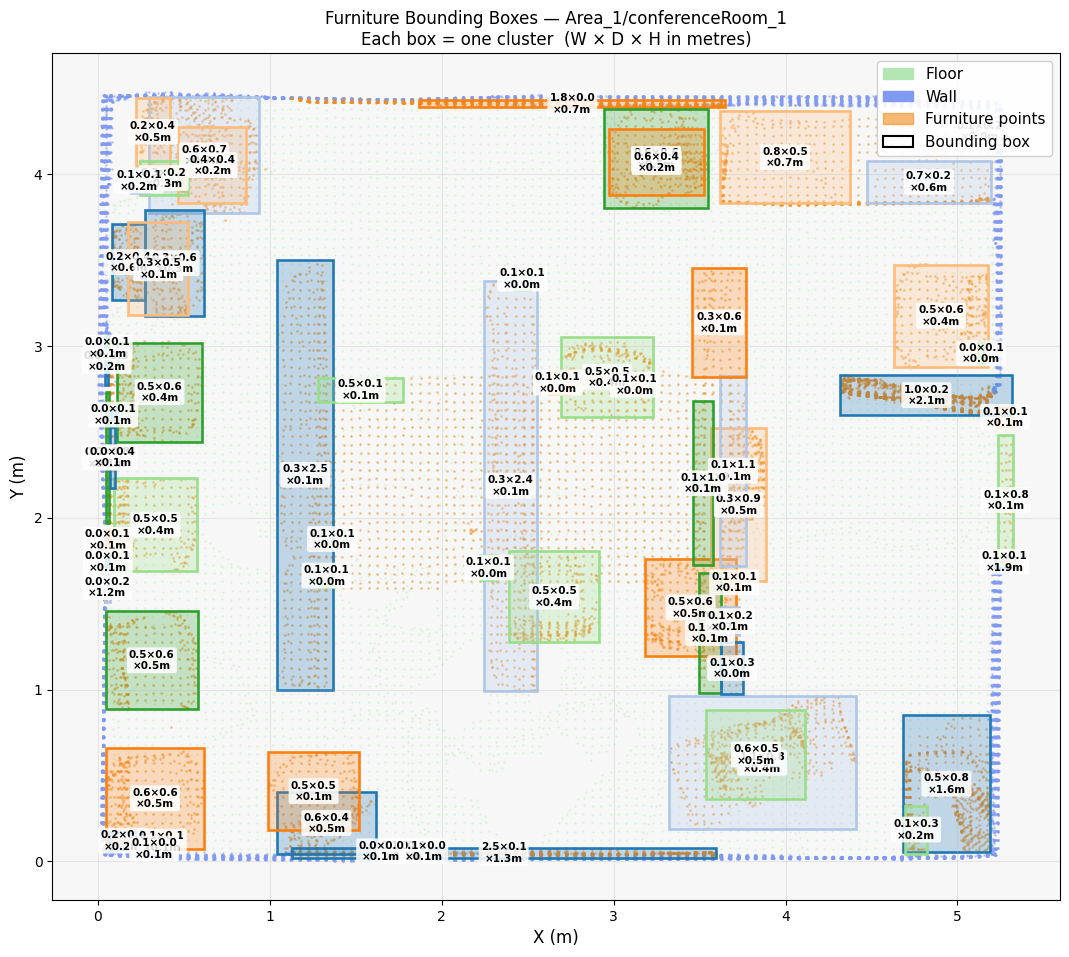

Saved → ./output\05_furniture_boxes.png
 cluster_id  count  x_spread  y_spread  z_spread  area_m2    cx    cy
         63   1676     0.999     0.235     2.134    0.235 4.771 2.701
         67    633     0.505     0.798     1.637    0.403 4.977 0.385
         34    603     2.467     0.057     1.309    0.139 2.682 0.051
         32    520     0.329     2.501     0.126    0.822 1.224 2.176
         42    507     0.307     2.383     0.139    0.731 2.415 2.085
         52    446     1.086     0.777     0.416    0.844 3.886 0.664
         28    423     0.637     0.674     0.712    0.429 0.618 4.111
         41    366     1.777     0.045     0.654    0.079 2.899 4.401
         51    341     0.530     0.562     0.471    0.298 3.439 1.425
          8    321     0.568     0.588     0.500    0.334 0.251 0.399
         57    317     0.319     0.894     0.468    0.285 3.768 2.169
         58    311     0.758     0.537     0.691    0.407 3.860 4.004
         65    306     0.548     0.595     0.430  

In [142]:
def plot_furniture_boxes(xyz, labels, df_clusters, cl_ids, out_dir, room_name):
    labs  = np.array(labels)
    furn  = df_clusters[df_clusters['semantic']=='furniture'].copy()
    print(f"Furniture clusters: {len(furn)}")
    if furn.empty:
        print("No furniture clusters to plot."); return

    fig,ax=plt.subplots(figsize=(13,13))
    ax.set_facecolor('#f7f7f7')

    # Background: floor points
    fm=labs=='floor'
    if fm.any():
        ax.scatter(xyz[fm,0],xyz[fm,1],c=[[0.7,0.9,0.7]],s=0.4,alpha=0.35,rasterized=True)

    # Background: wall points
    wm=labs=='wall'
    if wm.any():
        ax.scatter(xyz[wm,0],xyz[wm,1],c=[[0.5,0.6,0.95]],s=0.8,alpha=0.4,rasterized=True)

    # Furniture scatter
    furm=labs=='furniture'
    if furm.any():
        ax.scatter(xyz[furm,0],xyz[furm,1],c=[[0.95,0.55,0.10]],
                   s=1.2,alpha=0.35,rasterized=True)

    # Bounding boxes
    pal=plt.cm.tab20(np.linspace(0,1,max(len(furn),1)))
    for i,(_, row) in enumerate(furn.iterrows()):
        cid=int(row['cluster_id'])
        mask=cl_ids==cid
        if not mask.any(): continue
        cp=xyz[mask]
        xlo,xhi=cp[:,0].min(),cp[:,0].max()
        ylo,yhi=cp[:,1].min(),cp[:,1].max()
        w=xhi-xlo; d=yhi-ylo; h=row['z_spread']
        # skip huge boxes (walls/entire-room artefacts)
        if w>4.0 or d>4.0: continue
        rect=plt.Rectangle((xlo,ylo),w,d,
                            lw=1.8,edgecolor=pal[i%20],facecolor=pal[i%20],alpha=0.25)
        ax.add_patch(rect)
        border=plt.Rectangle((xlo,ylo),w,d,
                              lw=1.8,edgecolor=pal[i%20],facecolor='none')
        ax.add_patch(border)
        cx,cy=xlo+w/2,ylo+d/2
        ax.text(cx,cy,f"{w:.1f}×{d:.1f}\n×{h:.1f}m",
                ha='center',va='center',fontsize=7.5,fontweight='bold',
                color='black',
                bbox=dict(boxstyle='round,pad=0.2',fc='white',alpha=0.85,ec='none'))

    ax.set_xlabel("X (m)",fontsize=12); ax.set_ylabel("Y (m)",fontsize=12)
    ax.set_title(f"Furniture Bounding Boxes — {room_name}\n"
                 f"Each box = one cluster  (W × D × H in metres)",fontsize=12)
    ax.set_aspect('equal'); ax.grid(alpha=0.25)

    # Legend
    legend_items=[
        mpatches.Patch(color=[0.7,0.9,0.7],label='Floor'),
        mpatches.Patch(color=[0.5,0.6,0.95],label='Wall'),
        mpatches.Patch(color=[0.95,0.55,0.10],alpha=0.6,label='Furniture points'),
        mpatches.Patch(facecolor='none',edgecolor='black',lw=1.5,label='Bounding box'),
    ]
    ax.legend(handles=legend_items,fontsize=11,loc='upper right',framealpha=0.9)

    out=os.path.join(out_dir,"05_furniture_boxes.png")
    plt.savefig(out,dpi=150,bbox_inches='tight'); plt.show()
    print(f"Saved → {out}")
    # Print table
    show_cols=['cluster_id','count','x_spread','y_spread','z_spread','area_m2','cx','cy']
    print(furn[show_cols].sort_values('count',ascending=False).head(25).to_string(index=False))

plot_furniture_boxes(xyz_ds, sem_labels, df_clusters, cluster_ids, OUTPUT_DIR, f"{AREA}/{ROOM}")


In [143]:
print("="*60)
print("  GROUND TRUTH LABEL SUMMARY")
print("="*60)
cnt=Counter(sem_labels); total=len(sem_labels)
rows=[]
for lbl in ['floor','ceiling','wall','beam','window','furniture','noise']:
    n=cnt.get(lbl,0)
    rows.append({'Label':lbl,'Points':n,'Percentage':f"{100*n/total:.1f}%"})
df_summary=pd.DataFrame(rows)
print(df_summary.to_string(index=False))
print()
print("Since labels are loaded directly from S3DIS Annotations/,")
print("these represent the ground-truth distribution for this room.")


  GROUND TRUTH LABEL SUMMARY
    Label  Points Percentage
    floor    8284      16.6%
  ceiling    8943      17.9%
     wall   14851      29.7%
     beam    2485       5.0%
   window       0       0.0%
furniture   15453      30.9%
    noise       0       0.0%

Since labels are loaded directly from S3DIS Annotations/,
these represent the ground-truth distribution for this room.


In [145]:
print("="*60)
print("  PIPELINE COMPLETE")
print("="*60)
print(f"  Room      : {AREA}/{ROOM}")
print(f"  Points    : {len(xyz_ds):,} (after downsample)")
print(f"  Z span    : {xyz_ds[:,2].ptp():.2f} m  (room height)")
print(f"  Clusters  : {df_clusters['cluster_id'].nunique()}")
print()
cnt=Counter(sem_labels); total=len(sem_labels)
print("  Semantic label distribution:")
for lbl in ['floor','ceiling','wall','beam','window','furniture']:
    n=cnt.get(lbl,0)
    bar='█'*int(25*n/max(total,1))
    print(f"    {lbl:<11} {n:>8,}  {100*n/total:5.1f}%  {bar}")
print()
print("  Output files in ./output/:")
for fn in sorted(os.listdir(OUTPUT_DIR)):
    if fn.startswith('.'): continue
    sz=os.path.getsize(os.path.join(OUTPUT_DIR,fn))/1e3
    print(f"    {fn:<38}  ({sz:.0f} KB)")



  PIPELINE COMPLETE
  Room      : Area_1/conferenceRoom_1
  Points    : 50,016 (after downsample)
  Z span    : 3.18 m  (room height)
  Clusters  : 69

  Semantic label distribution:
    floor          8,284   16.6%  ████
    ceiling        8,943   17.9%  ████
    wall          14,851   29.7%  ███████
    beam           2,485    5.0%  █
    window             0    0.0%  
    furniture     15,453   30.9%  ███████

  Output files in ./output/:
    01_raw_rgb.png                          (1295 KB)
    02_segmentation_2d.png                  (1454 KB)
    03_dbscan_clusters.png                  (1539 KB)
    04_floor_plan.png                       (865 KB)
    05_furniture_boxes.png                  (715 KB)
    cluster_report.csv                      (4 KB)
    segmented_room.ply                      (1351 KB)
